# Comparison of modelling results: UCI (1994) vs ACS (2024)

No new modelling. Reads the two long-format results tables from notebooks 04 and 05, stacks them, and presents four cross-dataset comparisons:

1. Baseline fairness: how biased each dataset's untouched model is.
2. The proxy-removal reversal: whether removing protected attributes and proxies helps or harms, and how that differs by era.
3. Metric disagreement: where the five metrics move in different directions for the same intervention.
4. Model choice: whether LR and RF differ on fairness, by era.

Every figure is read from a committed CSV, so each number traces back to the notebook that produced it.

## 0. Setup and load

Both results tables are read and stacked. They share one schema :
`dataset, model, experiment, protected_attribute, metric, value` : so a single `concat` is
enough. 

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

RESULTS_DIR = "../results/tables"
FIGURES_DIR = "../results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

COLOURS = {"UCI Adult (1994)": "#4C72B0", "ACS PUMS (2024)": "#DD8452"}

uci = pd.read_csv(f"{RESULTS_DIR}/uci_model_results.csv")
acs = pd.read_csv(f"{RESULTS_DIR}/acs_model_results.csv")
res = pd.concat([uci, acs], ignore_index=True)

print("datasets:", res["dataset"].unique().tolist())
print("experiments:", sorted(res["experiment"].unique()))
print("models:", res["model"].unique().tolist())
print("metrics:", sorted(res["metric"].unique()))
n_metrics = res["metric"].nunique()
n_expected = 2 * 2 * 3 * 2 * n_metrics   # datasets x models x experiments x attributes x metrics
print("total rows:", len(res),
      f"(expect {n_expected}: 2 datasets x 2 models x 3 experiments x 2 attributes x {n_metrics} metrics)")

datasets: ['UCI Adult (1994)', 'ACS PUMS (2024)']
experiments: ['baseline', 'protected_removed_naive', 'protected_removed_proxies']
models: ['LogisticRegression', 'RandomForest']
metrics: ['DI', 'EOD', 'EqualisedOdds', 'PredictiveParity', 'SPD', 'accuracy', 'balanced_accuracy', 'f1', 'precision_overall', 'recall', 'roc_auc']
total rows: 264 (expect 264: 2 datasets x 2 models x 3 experiments x 2 attributes x 11 metrics)


In [17]:
# Fixed ordering so every table and chart reads baseline -> naive -> proxies left to right.
EXP_ORDER = ["baseline", "protected_removed_naive", "protected_removed_proxies"]
EXP_LABEL = {
    "baseline": "baseline",
    "protected_removed_naive": "naive removal",
    "protected_removed_proxies": "removal + proxies",
}
res["experiment"] = pd.Categorical(res["experiment"], categories=EXP_ORDER, ordered=True)

## 1. Baseline fairness : 1994 vs 2024

How biased is each dataset's untouched (baseline) model? This isolates the starting point: the degree of disparity a model reproduces when trained on all features.

In [18]:
baseline = res[res["experiment"] == "baseline"]
# Split by model as well as dataset, and use aggfunc="first" so no two cells
# are ever silently averaged together (LR and RF are reported separately,
# matching Table 1 in the report).
base_view = baseline.pivot_table(
    index=["protected_attribute", "metric"],
    columns=["dataset", "model"], values="value", aggfunc="first")
print(base_view.round(4))

dataset                                  ACS PUMS (2024)                UCI Adult (1994)             
model                                 LogisticRegression RandomForest LogisticRegression RandomForest
protected_attribute metric                                                                           
race_binary         DI                            0.7054       0.7352             0.5409       0.5462
                    EOD                           0.1113       0.0898             0.1021       0.0754
                    EqualisedOdds                 0.1113       0.0898             0.1021       0.0754
                    PredictiveParity              0.0487       0.0616             0.0463       0.0140
                    SPD                           0.1637       0.1408             0.0948       0.0983
                    accuracy                      0.7843       0.7629             0.8543       0.8519
                    balanced_accuracy             0.7845       0.7627             

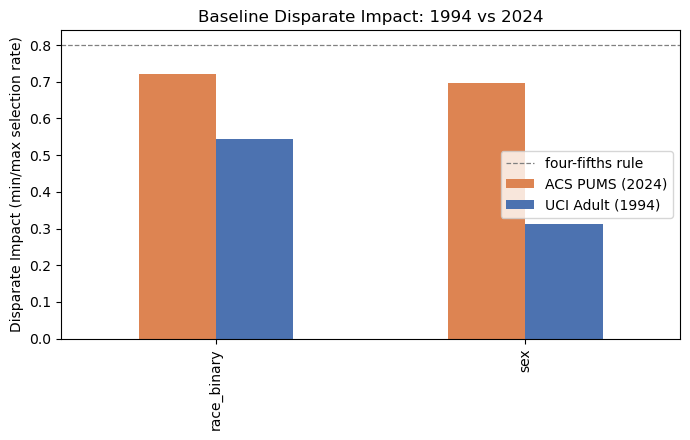

In [19]:
# Baseline Disparate Impact by dataset and attribute (higher = fairer; 0.8 = four-fifths line).
di_base = baseline[baseline["metric"] == "DI"].pivot_table(
    index="protected_attribute", columns="dataset", values="value")

ax = di_base.plot(kind="bar", figsize=(7, 4.5),
                  color=[COLOURS[c] for c in di_base.columns])
ax.axhline(0.8, color="grey", linestyle="--", linewidth=0.9, label="four-fifths rule")
ax.set_ylabel("Disparate Impact (min/max selection rate)")
ax.set_title("Baseline Disparate Impact: 1994 vs 2024")
ax.set_xlabel("")
ax.legend(title="")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/baseline_di_comparison.png", dpi=150)
plt.show()

### Findings : baseline fairness

Sex disparity is severe in both eras but less extreme in 2024: baseline DI for sex is 0.31 in 1994 against 0.70 in 2024. Race disparity is milder than sex in both (DI 0.54 vs 0.72). Both baselines fail the four-fifths rule (DI < 0.8) on both attributes, so an untouched model reproduces historical bias in both eras. Accuracy is higher on UCI (0.85) than ACS (0.77), reflecting the smaller, cleaner 1994 feature set.

## 2. The proxy-removal reversal : the central finding

Does removing protected attributes and their proxies improve fairness? The two eras answer
oppositely. This is the notebook's headline comparison: the same intervention, run through the
same pipeline, helps in one era and harms in the other. The Disparate Impact trajectory across
the three experiments makes it visible.

In [20]:
# Disparate Impact trajectory (baseline -> naive -> proxies) for sex, both datasets and
# both classifiers.
sex_di = res[(res["protected_attribute"] == "sex") & (res["metric"] == "DI")]
traj = sex_di.pivot_table(index="experiment", columns=["dataset", "model"], values="value")
print("Disparate Impact trajectory (SEX):")
print(traj.round(4))

Disparate Impact trajectory (SEX):
dataset                      ACS PUMS (2024)                UCI Adult (1994)             
model                     LogisticRegression RandomForest LogisticRegression RandomForest
experiment                                                                               
baseline                              0.6871       0.7063             0.3002       0.3266
protected_removed_naive               0.8450       0.8166             0.3178       0.3463
protected_removed_proxies             0.9343       0.9050             0.2665       0.3117


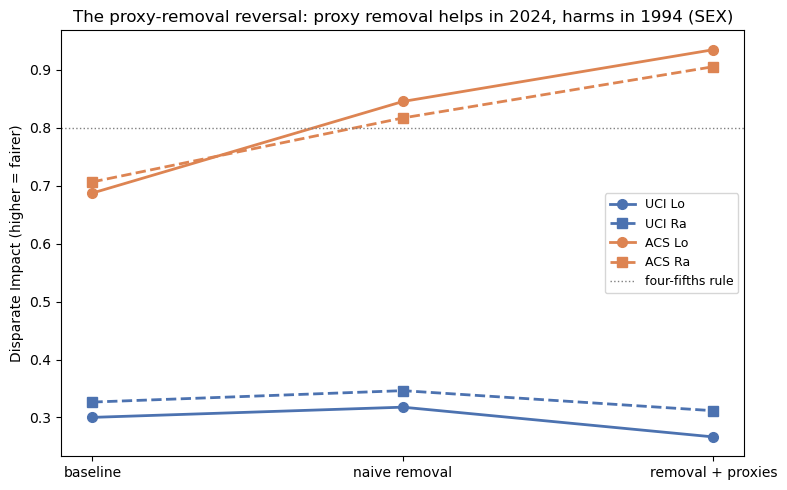

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(EXP_ORDER))
for dataset in ["UCI Adult (1994)", "ACS PUMS (2024)"]:
    for model, style in [("LogisticRegression", "-o"), ("RandomForest", "--s")]:
        sub = sex_di[(sex_di["dataset"] == dataset) & (sex_di["model"] == model)]
        sub = sub.set_index("experiment").reindex(EXP_ORDER)["value"]
        ax.plot(x, sub.values, style, color=COLOURS[dataset],
                label=f"{dataset.split(' ')[0]} {model[:2]}", linewidth=2, markersize=7)

ax.axhline(0.8, color="grey", linestyle=":", linewidth=1, label="four-fifths rule")
ax.set_xticks(x)
ax.set_xticklabels([EXP_LABEL[e] for e in EXP_ORDER])
ax.set_ylabel("Disparate Impact (higher = fairer)")
ax.set_title("The proxy-removal reversal: proxy removal helps in 2024, harms in 1994 (SEX)")
ax.legend(title="", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/proxy_removal_reversal.png", dpi=150)
plt.show()

### Findings : the proxy-removal reversal

The central result: the same intervention reverses direction across eras. In UCI 1994, sex DI falls when proxies are removed (0.30 to 0.27 for LR) : `relationship` carried legitimate income signal, so removing it harmed the disadvantaged group. In ACS 2024, sex DI rises toward parity (0.69 to 0.93 for LR) : `occupation` carried more separable bias and `relationship` had already collapsed as a proxy. This tracks the EDA proxy-strength change directly. Caveat: proxy removal also reduces feature count, so the effect is not purely proxy-specific. Accuracy falls in 2024 (0.784 to 0.753) as the proxies are dropped.

## 3. Metric disagreement : the impossibility result

Do the five fairness metrics agree on whether an intervention helped? They do not. For the
same proxy-removal step, selection-rate and opportunity metrics can improve while
predictive-parity worsens. This is the fairness-impossibility result : no single intervention
optimises all definitions at once : shown in the project's own numbers rather than cited.

In [22]:
# For ACS sex under Logistic Regression, every metric's change from baseline to proxy
# removal is shown. The metrics do not share a direction: DI rising is fairer, while SPD,
# EOD and Predictive Parity falling is fairer, so they move in different directions.
acs_sex_lr = res[(res["dataset"] == "ACS PUMS (2024)") &
                 (res["protected_attribute"] == "sex") &
                 (res["model"] == "LogisticRegression")]
change = acs_sex_lr.pivot_table(index="metric", columns="experiment", values="value")
change["baseline -> proxies"] = change["protected_removed_proxies"] - change["baseline"]
print("ACS 2024, SEX, Logistic Regression: metric values and net change:")
print(change.round(4))
print()
print("Direction of 'fairer': DI up; SPD, EOD, EqualisedOdds, PredictiveParity down.")

ACS 2024, SEX, Logistic Regression: metric values and net change:
experiment         baseline  protected_removed_naive  protected_removed_proxies  baseline -> proxies
metric                                                                                              
DI                   0.6871                   0.8450                     0.9343               0.2472
EOD                  0.1072                   0.0036                     0.0406              -0.0666
EqualisedOdds        0.1102                   0.0115                     0.0406              -0.0696
PredictiveParity     0.0344                   0.0904                     0.1186               0.0842
SPD                  0.1847                   0.0841                     0.0344              -0.1503
accuracy             0.7843                   0.7793                     0.7526              -0.0317
balanced_accuracy    0.7845                   0.7794                     0.7528              -0.0317
f1                   0.78

### Findings : metric disagreement

For ACS 2024 sex under proxy removal, DI, SPD, EOD and EqualisedOdds all move toward fairness while Predictive Parity worsens (0.034 to 0.119). Parity of selection/opportunity and parity of precision cannot both hold when group base rates differ : the impossibility result, shown in the project's own numbers. A practitioner choosing a mitigation must also choose which fairness definition to privilege.

## 4. Model choice and fairness

Does the choice between Logistic Regression and Random Forest affect fairness, and does that
differ by era? This compares the two models on the baseline, per dataset and attribute.

In [23]:
lr_rf = baseline.pivot_table(
    index=["dataset", "protected_attribute", "metric"],
    columns="model", values="value")
lr_rf["RF - LR"] = lr_rf["RandomForest"] - lr_rf["LogisticRegression"]
print("Baseline: Random Forest vs Logistic Regression (RF - LR):")
print(lr_rf.round(4))

Baseline: Random Forest vs Logistic Regression (RF - LR):
model                                                   LogisticRegression  RandomForest  RF - LR
dataset          protected_attribute metric                                                      
ACS PUMS (2024)  race_binary         DI                             0.7054        0.7352   0.0298
                                     EOD                            0.1113        0.0898  -0.0215
                                     EqualisedOdds                  0.1113        0.0898  -0.0215
                                     PredictiveParity               0.0487        0.0616   0.0129
                                     SPD                            0.1637        0.1408  -0.0229
                                     accuracy                       0.7843        0.7629  -0.0214
                                     balanced_accuracy              0.7845        0.7627  -0.0218
                                     f1                     

### Findings : model choice

On the baseline, Random Forest is slightly fairer than Logistic Regression on the error-based metrics (EOD, EqualisedOdds) in both eras, but slightly worse on the selection-rate metrics (higher DI, lower SPD) and on Predictive Parity. The direction is consistent across 1994 and 2024. RF's accuracy is lower than LR's in both datasets (e.g. ACS 0.763 vs 0.784), so the modest fairness gains carry an accuracy cost.

## 6. Additional robustness analyses

Reads the four supplementary result files from notebooks 04 and 05 (bootstrap CIs, ACS threshold sensitivity, race × sex intersectional, multi-seed robustness) into the cross-dataset comparison. Each subsection loads its own CSV and skips gracefully if the file is absent.

In [24]:
# Load the new result files. Missing files are tolerated so 06 runs incrementally.
def try_load(name):
    path = f"{RESULTS_DIR}/{name}"
    try:
        df = pd.read_csv(path)
        print(f"loaded {name}: {len(df)} rows")
        return df
    except FileNotFoundError:
        print(f"[skip] {name} not found: run its cell in 04/05 first")
        return None

uci_ci    = try_load("uci_ci_baseline.csv")
acs_ci    = try_load("acs_ci_baseline.csv")
thr       = try_load("acs_threshold_results.csv")
uci_inter = try_load("uci_intersectional.csv")
acs_inter = try_load("acs_intersectional.csv")
acs_inter_matched = try_load("acs_intersectional_matched.csv")
ms_sum    = try_load("acs_multiseed_summary.csv")


loaded uci_ci_baseline.csv: 20 rows
loaded acs_ci_baseline.csv: 20 rows
loaded acs_threshold_results.csv: 132 rows
loaded uci_intersectional.csv: 10 rows
loaded acs_intersectional.csv: 10 rows
loaded acs_intersectional_matched.csv: 12 rows
loaded acs_multiseed_summary.csv: 44 rows


### 6.1 Baseline fairness with 95% confidence intervals

The baseline Disparate Impact and SPD gaps from Section 1, now shown with bootstrap intervals so that a 1994–2024 difference can be judged against sampling noise rather than read from point estimates alone.

In [25]:
# Combine both datasets' CI tables and show intervals side by side.
if uci_ci is not None and acs_ci is not None:
    ci = pd.concat([uci_ci, acs_ci], ignore_index=True)
    # focus on the headline selection-based metrics for the comparison
    show = ci[ci["metric"].isin(["DI", "SPD"])].copy()
    show["CI"] = show.apply(lambda r: f'{r["value"]:.3f} [{r["ci_low"]:.3f}, {r["ci_high"]:.3f}]', axis=1)
    table = show.pivot_table(index=["protected_attribute", "metric", "model"],
                             columns="dataset", values="CI", aggfunc="first")
    print("Baseline DI and SPD with 95% bootstrap CIs:")
    print(table)

    # Do the 1994 and 2024 intervals overlap? A quick non-overlap flag per (attr, metric, model).
    def overlap_flag(sub):
        piv = sub.pivot_table(index="dataset", values=["ci_low","ci_high"], aggfunc="first")
        if piv.shape[0] < 2: return "n/a"
        (lo1, hi1), (lo2, hi2) = piv[["ci_low","ci_high"]].values
        return "separated" if (hi1 < lo2 or hi2 < lo1) else "overlapping"
    flags = (show.groupby(["protected_attribute","metric","model"])
                  .apply(overlap_flag, include_groups=False)
                  .rename("CI_overlap").reset_index())
    print("\nDo the 1994 vs 2024 intervals overlap?")
    print(flags.to_string(index=False))
else:
    print("CI files not both present: run bootstrap cells in 04 and 05.")


Baseline DI and SPD with 95% bootstrap CIs:
dataset                                             ACS PUMS (2024)      UCI Adult (1994)
protected_attribute metric model                                                         
race_binary         DI     LogisticRegression  0.705 [0.690, 0.721]  0.541 [0.473, 0.615]
                           RandomForest        0.735 [0.719, 0.755]  0.546 [0.483, 0.620]
                    SPD    LogisticRegression  0.164 [0.154, 0.173]  0.095 [0.079, 0.110]
                           RandomForest        0.141 [0.129, 0.150]  0.098 [0.081, 0.114]
sex                 DI     LogisticRegression  0.687 [0.676, 0.701]  0.300 [0.268, 0.331]
                           RandomForest        0.706 [0.694, 0.723]  0.327 [0.294, 0.361]
                    SPD    LogisticRegression  0.185 [0.176, 0.192]  0.175 [0.164, 0.186]
                           RandomForest        0.166 [0.155, 0.174]  0.175 [0.163, 0.186]

Do the 1994 vs 2024 intervals overlap?
protected_attrib

### 6.2 Threshold sensitivity (ACS)

The $50k threshold is not comparable across thirty years: in 1994 it selected the top 23.93% of earners, but the same nominal figure selects roughly half of 2024 earners. This compares ACS baseline fairness at the nominal, inflation-adjusted, and quantile-matched thresholds. The quantile-matched run reproduces the 1994 positive rate, so if the fairness picture holds there, the temporal comparison is not merely a threshold artefact.


sex fairness across thresholds:
experiment threshold_nominal_50k              threshold_inflation_105833              threshold_quantile_matched             
model         LogisticRegression RandomForest         LogisticRegression RandomForest         LogisticRegression RandomForest
metric                                                                                                                       
DI                        0.6871       0.7063                     0.2696       0.4410                     0.3992       0.5167
EOD                       0.1072       0.0985                     0.2826       0.1696                     0.2267       0.1523
SPD                       0.1847       0.1659                     0.1316       0.1070                     0.1494       0.1229

race_binary fairness across thresholds:
experiment threshold_nominal_50k              threshold_inflation_105833              threshold_quantile_matched             
model         LogisticRegression RandomFores

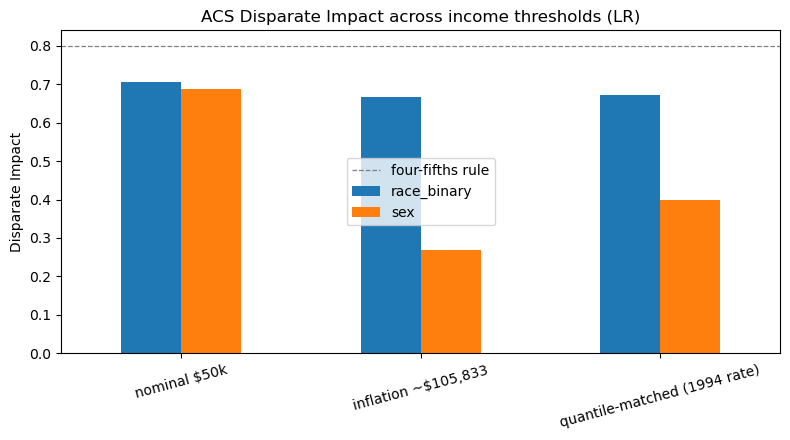

In [26]:
if thr is not None:
    THR_ORDER = ["threshold_nominal_50k", "threshold_inflation_105833", "threshold_quantile_matched"]
    THR_LABEL = {"threshold_nominal_50k": "nominal $50k",
                 "threshold_inflation_105833": "inflation ~$105,833",
                 "threshold_quantile_matched": "quantile-matched (1994 rate)"}
    t = thr[thr["experiment"].isin(THR_ORDER)].copy()
    t["experiment"] = pd.Categorical(t["experiment"], categories=THR_ORDER, ordered=True)
    for attr in ["sex", "race_binary"]:
        view = (t[(t["protected_attribute"]==attr) & (t["metric"].isin(["DI","SPD","EOD"]))]
                  .pivot_table(index="metric", columns=["experiment","model"], values="value"))
        print(f"\n{attr} fairness across thresholds:")
        print(view.round(4))

    # Plot DI across thresholds (LogisticRegression, both attributes).
    di_t = (t[(t["metric"]=="DI") & (t["model"]=="LogisticRegression")]
              .pivot_table(index="experiment", columns="protected_attribute", values="value"))
    di_t.index = [THR_LABEL[i] for i in di_t.index]
    ax = di_t.plot(kind="bar", figsize=(8,4.5))
    ax.axhline(0.8, color="grey", linestyle="--", linewidth=0.9, label="four-fifths rule")
    ax.set_ylabel("Disparate Impact"); ax.set_title("ACS Disparate Impact across income thresholds (LR)")
    ax.set_xlabel(""); plt.xticks(rotation=15); plt.legend(title=""); plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/acs_threshold_di.png", dpi=150); plt.show()
else:
    print("acs_threshold_results.csv not found: run the threshold cell in 05.")


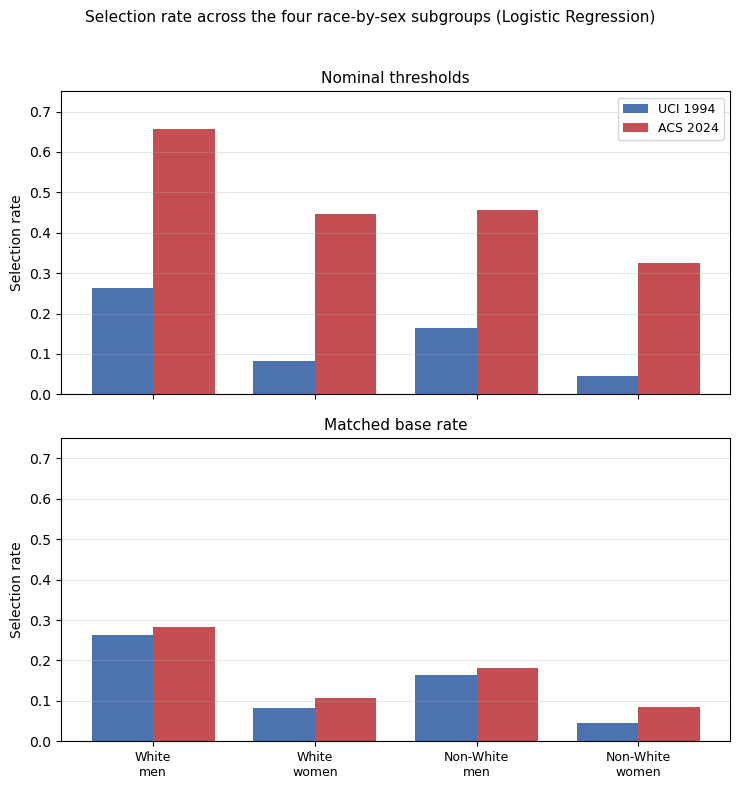

written: ../results/figures/intersectional_subgroups.png


In [27]:
# Figure 4: four-subgroup selection rate, nominal vs matched base rate (Logistic Regression).
# The top panel shows the apparent widening at nominal thresholds; the bottom panel shows
# that at a matched base rate the 2024 spread is proportionally tighter, so the widening
# was an artefact.
import numpy as np

SUB_ORDER = ["White / Male", "White / Female", "Non-White / Male", "Non-White / Female"]
SUB_LABELS = ["White\nmen", "White\nwomen", "Non-White\nmen", "Non-White\nwomen"]
MODEL = "LogisticRegression"

def _rates(df, model):
    sub = df[(df["model"] == model) &
             (~df["subgroup"].str.contains("GAP|RATIO", regex=True))]
    s = sub.set_index("subgroup")["selection_rate"]
    return [float(s.get(k, np.nan)) for k in SUB_ORDER]

if uci_inter is not None and acs_inter is not None and acs_inter_matched is not None:
    uci_r = _rates(uci_inter, MODEL)          # 1994 (nominal == matched base rate)
    acs_nom = _rates(acs_inter, MODEL)         # 2024 nominal $50k
    acs_mat = _rates(acs_inter_matched, MODEL) # 2024 quantile-matched

    fig, axes = plt.subplots(2, 1, figsize=(7.5, 8.0), sharex=True)
    x = np.arange(len(SUB_ORDER)); w = 0.38
    panels = [("Nominal thresholds", uci_r, acs_nom),
              ("Matched base rate", uci_r, acs_mat)]
    for ax, (title, uci_bars, acs_bars) in zip(axes, panels):
        ax.bar(x - w/2, uci_bars, w, label="UCI 1994", color="#4C72B0")
        ax.bar(x + w/2, acs_bars, w, label="ACS 2024", color="#C44E52")
        ax.set_title(title, fontsize=11)
        ax.set_xticks(x); ax.set_xticklabels(SUB_LABELS, fontsize=9)
        ax.set_ylim(0, 0.75); ax.grid(axis="y", alpha=0.3)
    for ax in axes:
        ax.set_ylabel("Selection rate")
    axes[0].legend(loc="upper right", fontsize=9)
    fig.suptitle("Selection rate across the four race-by-sex subgroups (Logistic Regression)",
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(f"{FIGURES_DIR}/intersectional_subgroups.png", dpi=150)
    plt.show()
    print(f"written: {FIGURES_DIR}/intersectional_subgroups.png")
else:
    print("intersectional inputs missing; run the matched cell in 05 and reload in cell 19.")

### 6.3 Intersectional analysis (race × sex)

Selection and true-positive rates for the four race × sex subgroups at baseline, for each dataset. A model that looks fair on race and on sex separately can still show a large gap for a specific combination; the max–min gap row quantifies that.

In [28]:
# Matched-base-rate intersectional comparison. The 1994 nominal threshold already sits at
# a 23.9% positive rate, so the 1994 baseline is directly comparable to the ACS
# quantile-matched (23.5%) intersectional audit. Absolute gaps are confounded by base
# rate, so the min/max ratio is reported as the summary.
if uci_inter is not None and acs_inter_matched is not None:
    def _summ(df, model):
        sub = df[(df["model"] == model) &
                 (~df["subgroup"].str.contains("GAP|RATIO", regex=True))]
        smin, smax = sub["selection_rate"].min(), sub["selection_rate"].max()
        return smin, smax, round(smax - smin, 4), round(smin / smax, 4)

    print("Intersectional race x sex: 1994 baseline vs 2024 quantile-matched")
    print(f"{'model':20}{'era':18}{'min':>8}{'max':>8}{'ABSgap':>9}{'RATIO':>8}")
    for model in ["LogisticRegression", "RandomForest"]:
        for era, df in [("1994 baseline", uci_inter),
                        ("2024 matched", acs_inter_matched)]:
            lo, hi, g, r = _summ(df, model)
            print(f"{model:20}{era:18}{lo:8.4f}{hi:8.4f}{g:9.4f}{r:8.4f}")
        print()

    # Tidy comparison table for the appendix / report.
    rows = []
    for model in ["LogisticRegression", "RandomForest"]:
        lo9, hi9, g9, r9 = _summ(uci_inter, model)
        lo2, hi2, g2, r2 = _summ(acs_inter_matched, model)
        rows.append({"model": model,
                     "abs_gap_1994": g9, "abs_gap_2024_matched": g2,
                     "ratio_1994": r9, "ratio_2024_matched": r2})
    inter_matched_cmp = pd.DataFrame(rows)
    inter_matched_cmp.to_csv(f"{RESULTS_DIR}/intersectional_matched_comparison.csv", index=False)
    print(inter_matched_cmp.to_string(index=False))
    print(f"\nwritten: {RESULTS_DIR}/intersectional_matched_comparison.csv")
else:
    print("matched intersectional or uci_inter not found: run the matched cell in 05 first.")

Intersectional race x sex: 1994 baseline vs 2024 quantile-matched
model               era                    min     max   ABSgap   RATIO
LogisticRegression  1994 baseline       0.0448  0.2622   0.2174  0.1709
LogisticRegression  2024 matched        0.0840  0.2825   0.1985  0.2973

RandomForest        1994 baseline       0.0398  0.2708   0.2310  0.1470
RandomForest        2024 matched        0.1168  0.2958   0.1790  0.3949

             model  abs_gap_1994  abs_gap_2024_matched  ratio_1994  ratio_2024_matched
LogisticRegression        0.2174                0.1985      0.1709              0.2973
      RandomForest        0.2310                0.1790      0.1470              0.3949

written: ../results/tables/intersectional_matched_comparison.csv


In [29]:
frames = [f for f in [uci_inter, acs_inter] if f is not None]
if frames:
    inter = pd.concat(frames, ignore_index=True)
    for ds in inter["dataset"].unique():
        sub = inter[(inter["dataset"]==ds) & (inter["model"]=="LogisticRegression")]
        print(f"\n{ds} race x sex (LogisticRegression):")
        print(sub[["subgroup","n","selection_rate","tpr","precision"]].to_string(index=False))
    # Compare the intersectional selection-rate GAP across datasets and models.
    gaps = inter[inter["subgroup"]=="GAP (max-min)"]
    gap_view = gaps.pivot_table(index="model", columns="dataset", values="selection_rate")
    print("\nIntersectional selection-rate gap (max-min across the four subgroups):")
    print(gap_view.round(4))
else:
    print("intersectional CSVs not found: run the intersectional cells in 04 and 05.")



UCI Adult (1994) race x sex (LogisticRegression):
          subgroup     n  selection_rate    tpr  precision
Non-White / Female   804          0.0448 0.4483     0.7222
  Non-White / Male  1022          0.1644 0.5200     0.6964
    White / Female  3220          0.0826 0.5165     0.7669
      White / Male  7165          0.2622 0.6234     0.7445
     GAP (max-min) 12211          0.2175 0.1752     0.0705

ACS PUMS (2024) race x sex (LogisticRegression):
          subgroup     n  selection_rate    tpr  precision
Non-White / Female  7175          0.3242 0.6613     0.7386
  Non-White / Male  7487          0.4569 0.7479     0.7387
    White / Female 14036          0.4473 0.7552     0.7593
      White / Male 15093          0.6565 0.8671     0.8051
     GAP (max-min) 43791          0.3323 0.2058     0.0665

Intersectional selection-rate gap (max-min across the four subgroups):
dataset             ACS PUMS (2024)  UCI Adult (1994)
model                                                
LogisticReg

### 6.4 Multi-seed robustness (ACS)

The ACS baseline re-run across five random subsamples matched to the 1994 dataset size. The standard deviation across seeds shows how much of the headline figure is subsample-dependent; a small spread means the reported baseline is stable.

In [30]:
if ms_sum is not None:
    show = ms_sum[ms_sum["metric"].isin(["DI","SPD","EOD","accuracy"])].copy()
    print("ACS baseline across seeds (mean ± std, min–max):")
    show["summary"] = show.apply(lambda r: f'{r["mean"]:.3f} ± {r["std"]:.3f}  [{r["min"]:.3f}, {r["max"]:.3f}]', axis=1)
    print(show.pivot_table(index=["protected_attribute","metric"], columns="model",
                           values="summary", aggfunc="first"))
    worst = ms_sum.loc[ms_sum["std"].idxmax()]
    print(f'\nLargest spread: {worst["metric"]} on {worst["protected_attribute"]} '
          f'({worst["model"]}), std = {worst["std"]:.4f}')
else:
    print("acs_multiseed_summary.csv not found: run the multi-seed cell in 05.")


ACS baseline across seeds (mean ± std, min–max):
model                                    LogisticRegression                   RandomForest
protected_attribute metric                                                                
race_binary         DI        0.697 ± 0.020  [0.681, 0.729]  0.725 ± 0.018  [0.710, 0.757]
                    EOD       0.121 ± 0.025  [0.087, 0.149]  0.101 ± 0.014  [0.084, 0.118]
                    SPD       0.170 ± 0.012  [0.150, 0.179]  0.149 ± 0.010  [0.131, 0.158]
                    accuracy  0.787 ± 0.003  [0.784, 0.791]  0.766 ± 0.003  [0.762, 0.770]
sex                 DI        0.694 ± 0.011  [0.674, 0.701]  0.704 ± 0.019  [0.677, 0.726]
                    EOD       0.098 ± 0.014  [0.085, 0.116]  0.094 ± 0.020  [0.072, 0.117]
                    SPD       0.181 ± 0.008  [0.176, 0.195]  0.170 ± 0.012  [0.156, 0.188]
                    accuracy  0.787 ± 0.003  [0.784, 0.791]  0.766 ± 0.003  [0.762, 0.770]

Largest spread: EOD on race_binary (Logi

## 5. Summary

Four findings:

1. **Baseline bias persists in both eras.** Both baselines fail the four-fifths rule on both attributes, so historical bias is reproduced by untouched models in 1994 and 2024 alike.

2. **The proxy-removal reversal.** Proxy removal harms fairness in 1994 (sex DI 0.30 to 0.27) but helps in 2024 (0.69 to 0.93), explained by the EDA proxy-strength change.

3. **Metric disagreement.** Under the same intervention, selection and opportunity metrics move opposite to predictive parity, demonstrating the impossibility result.

4. **Model choice has a small, era-consistent effect.** RF is marginally fairer on error-based metrics, at an accuracy cost.

Against the research questions: bias has not simply lessened over 30 years. Its structure has changed, and so has the effect of a standard proxy-removal intervention. The intersectional analysis (Section 6.3) sharpens this, but only once base rates are matched. Read at each dataset's own nominal threshold the four-subgroup selection-rate gap appears to widen, but that comparison is confounded by base rate exactly as the single-axis metrics were: the 2024 nominal task selects roughly 49% of earners against 24% in 1994, and an absolute gap is mechanically larger when more people are selected. Re-run at the quantile-matched threshold and measured as a min/max ratio (the same construction as Disparate Impact), the intersectional disparity is *less* severe in 2024 than in 1994 under both classifiers: the ratio rises from 0.171 to 0.297 for Logistic Regression and from 0.147 to 0.395 for Random Forest. The apparent widening was itself a base-rate artefact. What persists is the ordering: White men most-selected, Non-White women least-selected, in both eras and under both classifiers. The defensible reading is that intersectional disparity has narrowed proportionally but not disappeared, and its hierarchy is intact.